# 02 — Fine-tuning DistilBERT & Benchmark

**E-commerce Review Sentiment & CS Flagging System**

- **Phase 3 — Production model:** fine-tune `distilbert-base-uncased` with the Hugging Face `Trainer` on the
  **same splits** produced in notebook 01, then save model + tokenizer to `models/distilbert/`.
- **Phase 4 — Benchmark:** evaluate BiLSTM and DistilBERT on the same independent test set
  (Accuracy, Precision, Recall, F1, classification report, confusion matrix).
- **Phase 5 check:** run the CS-flagging test cases through the full pipeline.

Acceptance target: **DistilBERT test accuracy > 90%**.

## 0. Setup

In [1]:
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ndchien2004/ecommerce-sentiment-analyzer.git"


def find_repo_root() -> Path:
    """Use the local repo if we are inside it, otherwise (e.g. Kaggle) clone it."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "src" / "config.py").exists():
            return candidate
    target = Path.cwd() / "ecommerce-sentiment-analyzer"
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(target)], check=True)
    return target


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Repo root:", ROOT)

Repo root: D:\E-commerce Review Sentiment & CS Flagging System


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import transformers
from datasets import Dataset
from IPython.display import Image, display
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

from src import config
from src.data_utils import get_device, prepare_splits, set_seed
from src.evaluation import benchmark_table, compute_metrics, evaluate_predictor
from src.inference import AVAILABLE_MODELS, analyze_review

set_seed(config.SEED)
device = get_device()
sns.set_theme(style="whitegrid")
print(f"PyTorch {torch.__version__} | Transformers {transformers.__version__} | device: {device}")

PyTorch 2.11.0+cu128 | Transformers 5.17.0 | device: cuda


## 1. Load the shared splits

`prepare_splits()` reads `data/processed/*.csv` written by notebook 01. On a fresh machine it rebuilds them
deterministically (same seed, same shard), so the test set is identical either way.

In [3]:
splits = prepare_splits()
train_df, val_df, test_df = splits["train"], splits["val"], splits["test"]
pd.DataFrame({name: df["label"].map(config.ID2LABEL).value_counts() for name, df in splits.items()}).T

label,Negative,Positive
train,8000,8000
val,1000,1000
test,1000,1000


# Phase 3 — DistilBERT

## 2. Tokenizer and sequence length

We check how many reviews exceed `MAX_LENGTH` WordPiece tokens before truncating.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(config.DISTILBERT_MODEL_NAME)
token_lengths = pd.Series([len(ids) for ids in tokenizer(train_df["text"].tolist())["input_ids"]])
print(token_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))
print(f"Truncated at MAX_LENGTH={config.MAX_LENGTH}: {(token_lengths > config.MAX_LENGTH).mean():.2%} of reviews")

count    16000.0
mean       104.0
std         55.5
min         21.0
50%         93.0
90%        189.0
95%        210.0
99%        237.0
max        349.0
dtype: float64
Truncated at MAX_LENGTH=256: 0.19% of reviews


In [5]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=config.MAX_LENGTH)


hf_splits = {
    name: Dataset.from_pandas(df[["text", "label"]]).map(tokenize_batch, batched=True, remove_columns=["text"])
    for name, df in splits.items()
}
hf_splits["train"]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 16000
})

## 3. Model & training configuration

- Dynamic padding (`DataCollatorWithPadding`) keeps batches short.
- Evaluation every epoch on the **validation** split; the best checkpoint by validation loss is restored
  at the end (`load_best_model_at_end`).
- Mixed precision (fp16) when a GPU is available.

In [6]:
set_seed(config.SEED)
model = AutoModelForSequenceClassification.from_pretrained(
    config.DISTILBERT_MODEL_NAME,
    num_labels=config.NUM_CLASSES,
    id2label=config.ID2LABEL,
    label2id=config.LABEL2ID,
)


def trainer_metrics(eval_pred):
    logits, labels = eval_pred
    return compute_metrics(labels, np.argmax(logits, axis=-1))


training_args = TrainingArguments(
    output_dir=str(config.MODELS_DIR / "distilbert_trainer_output"),
    num_train_epochs=config.DISTILBERT_NUM_EPOCHS,
    learning_rate=config.DISTILBERT_LEARNING_RATE,
    per_device_train_batch_size=config.DISTILBERT_BATCH_SIZE,
    per_device_eval_batch_size=config.DISTILBERT_BATCH_SIZE * 2,
    weight_decay=config.DISTILBERT_WEIGHT_DECAY,
    warmup_steps=config.DISTILBERT_WARMUP_RATIO,  # a float < 1 is a ratio of total steps in transformers 5
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    seed=config.SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_splits["train"],
    eval_dataset=hf_splits["val"],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=trainer_metrics,
)

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 4. Fine-tune

In [7]:
train_result = trainer.train()
print(train_result.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.177942,0.190264,0.932000,0.932998,0.932000,0.931961
2,0.133034,0.204018,0.939000,0.939028,0.939000,0.938999


{'train_runtime': 283.1446, 'train_samples_per_second': 113.016, 'train_steps_per_second': 7.064, 'total_flos': 1746971774262912.0, 'train_loss': 0.19844340372085573, 'epoch': 2.0}


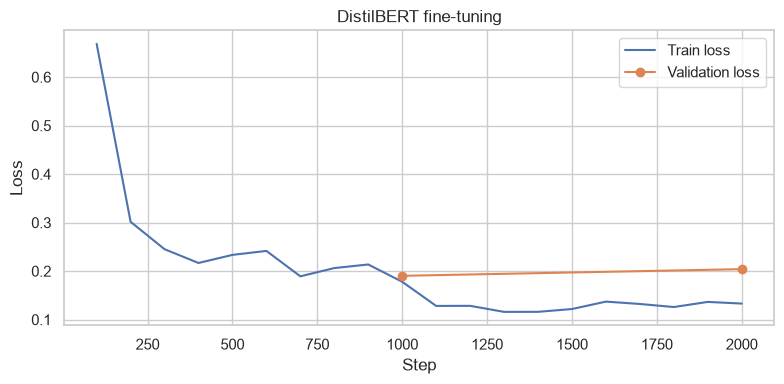

,epoch,step,eval_loss,eval_accuracy,eval_f1
10,1.0,1000,0.1903,0.932,0.932
21,2.0,2000,0.2040,0.939,0.939


In [8]:
log = pd.DataFrame(trainer.state.log_history)
train_log = log.dropna(subset=["loss"])[["step", "loss"]] if "loss" in log else pd.DataFrame()
eval_log = log.dropna(subset=["eval_loss"])[["epoch", "step", "eval_loss", "eval_accuracy", "eval_f1"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_log["step"], train_log["loss"], label="Train loss")
ax.plot(eval_log["step"], eval_log["eval_loss"], marker="o", label="Validation loss")
ax.set(title="DistilBERT fine-tuning", xlabel="Step", ylabel="Loss")
ax.legend()
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "distilbert_training_curves.png", dpi=150)
plt.show()
eval_log.round(4)

## 5. Save model + tokenizer to `models/distilbert/`

In [9]:
trainer.save_model(str(config.DISTILBERT_DIR))
tokenizer.save_pretrained(str(config.DISTILBERT_DIR))
sorted(p.name for p in config.DISTILBERT_DIR.iterdir())

['config.json',
 'model.safetensors',
 'tokenizer.json',
 'tokenizer_config.json',
 'training_args.bin']

# Phase 4 — Evaluation & Benchmark

## 6. Evaluate both models on the same test set

Both models are loaded from `models/` through `src/inference.py` — exactly what the Gradio app runs —
and scored on the identical held-out test split.

In [10]:
del trainer, model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

texts, labels = test_df["text"].tolist(), test_df["label"].tolist()
results = {name: evaluate_predictor(name, texts, labels) for name in AVAILABLE_MODELS}


=== BiLSTM ===
              precision    recall  f1-score   support

    Negative     0.8812    0.8460    0.8633      1000
    Positive     0.8519    0.8860    0.8686      1000

    accuracy                         0.8660      2000
   macro avg     0.8666    0.8660    0.8659      2000
weighted avg     0.8666    0.8660    0.8659      2000




=== DistilBERT ===
              precision    recall  f1-score   support

    Negative     0.9609    0.8840    0.9208      1000
    Positive     0.8926    0.9640    0.9269      1000

    accuracy                         0.9240      2000
   macro avg     0.9267    0.9240    0.9239      2000
weighted avg     0.9267    0.9240    0.9239      2000



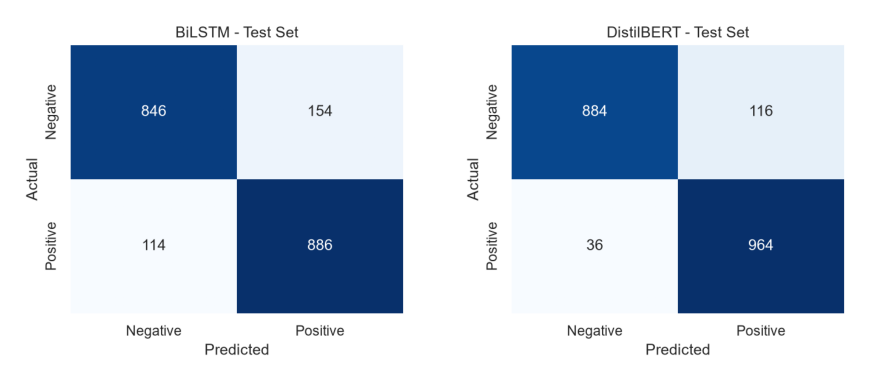

In [11]:
fig, axes = plt.subplots(1, len(AVAILABLE_MODELS), figsize=(9, 4))
for ax, name in zip(axes, AVAILABLE_MODELS):
    ax.imshow(plt.imread(config.FIGURES_DIR / f"confusion_matrix_{name.lower()}.png"))
    ax.axis("off")
fig.tight_layout()
plt.show()

## 7. Benchmark table

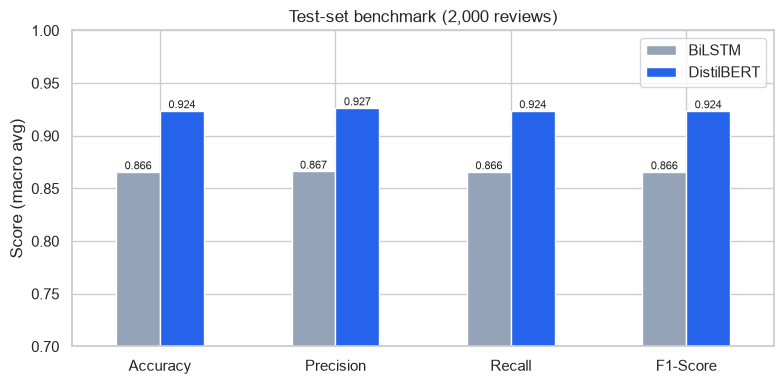

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| BiLSTM | 86.60% | 86.66% | 86.60% | 86.59% |
| DistilBERT | 92.40% | 92.67% | 92.40% | 92.39% |


,Accuracy,Precision,Recall,F1-Score
BiLSTM,0.866,0.8666,0.866,0.8659
DistilBERT,0.924,0.9267,0.924,0.9239


In [12]:
benchmark_df = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1"]]
benchmark_df.columns = ["Accuracy", "Precision", "Recall", "F1-Score"]

ax = benchmark_df.T.plot(kind="bar", figsize=(8, 4), ylim=(0.7, 1.0), rot=0, color=["#94a3b8", "#2563eb"])
ax.set(title=f"Test-set benchmark ({len(test_df):,} reviews)", ylabel="Score (macro avg)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "benchmark.png", dpi=150)
plt.show()

table = benchmark_table(AVAILABLE_MODELS)
(config.REPORTS_DIR / "benchmark.md").write_text(
    f"Test set: {len(test_df)} reviews (balanced, never used for training or tuning).\n\n{table}\n",
    encoding="utf-8",
)
print(table)
benchmark_df.round(4)

In [13]:
distilbert_acc = results["DistilBERT"]["accuracy"]
print(f"DistilBERT test accuracy: {distilbert_acc:.2%} -> target > 90%: {'PASS' if distilbert_acc > 0.90 else 'FAIL'}")

DistilBERT test accuracy: 92.40% -> target > 90%: PASS


# Phase 5 — CS Flagging check

A review is flagged **🔴 URGENT: TRANSFER TO CS** only when it is *Negative* **and** confidence > 80% **and** it
contains an emergency keyword (`fake, scam, broken, refund, worst, terrible, dangerous`).

In [14]:
CASES = [
    ("Positive review", "The product is excellent. Great quality and fast delivery!"),
    ("Negative, not urgent", "The product quality is disappointing. I don't really like it."),
    ("Negative + keyword", "This item looks fake and I want a refund immediately."),
    ("Keyword, positive", "The refund process was simple and the support team was great."),
    ("Acceptance test", "The product arrived completely broken and smells dangerous, I want a refund now!"),
]


def run_cases(model_name: str) -> pd.DataFrame:
    rows = []
    for case, text in CASES:
        result = analyze_review(text, model_name)
        rows.append({
            "case": case,
            "review": text,
            "sentiment": result.prediction.sentiment,
            "confidence": f"{result.prediction.confidence:.1%}",
            "keywords": ", ".join(result.flag.matched_keywords) or "-",
            "cs_flag": result.flag.label,
        })
    return pd.DataFrame(rows)

In [15]:
pd.concat({name: run_cases(name) for name in AVAILABLE_MODELS}, names=["model"]).droplevel(1)

,case,review,sentiment,confidence,keywords,cs_flag
model,,,,,,
BiLSTM,Positive review,The product is excellent. Great quality and fa...,Positive,99.8%,-,✅ Normal
BiLSTM,"Negative, not urgent",The product quality is disappointing. I don't ...,Negative,99.8%,-,✅ Normal
BiLSTM,Negative + keyword,This item looks fake and I want a refund immed...,Negative,99.4%,"fake, refund",🔴 URGENT: TRANSFER TO CS
BiLSTM,"Keyword, positive",The refund process was simple and the support ...,Positive,97.1%,refund,✅ Normal
BiLSTM,Acceptance test,The product arrived completely broken and smel...,Negative,86.5%,"broken, dangerous, refund",🔴 URGENT: TRANSFER TO CS
DistilBERT,Positive review,The product is excellent. Great quality and fa...,Positive,99.4%,-,✅ Normal
DistilBERT,"Negative, not urgent",The product quality is disappointing. I don't ...,Negative,99.5%,-,✅ Normal
DistilBERT,Negative + keyword,This item looks fake and I want a refund immed...,Negative,99.3%,"fake, refund",🔴 URGENT: TRANSFER TO CS
DistilBERT,"Keyword, positive",The refund process was simple and the support ...,Positive,97.1%,refund,✅ Normal


## Summary

- DistilBERT is saved in `models/distilbert/` (model + tokenizer) and is the default model of the app.
- Both models were scored on the same 2,000-review test set; results are in `reports/benchmark.md`,
  `reports/metrics_*.json` and `reports/figures/`.
- The CS-flagging rule is implemented independently of the models in `src/flagging_logic.py`.